In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from time import time
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
import graphviz
import pydot
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import os
from collections import defaultdict
import cv2

import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
data_dir = "/kaggle/input/corn-or-maize-leaf-disease-dataset/data"
classes=os.listdir(data_dir)

In [ ]:
print(classes)

['Common_Rust', 'Blight', 'Healthy', 'Gray_Leaf_Spot']


In [ ]:
for cls in classes:
  num_images = len(os.listdir(os.path.join(data_dir, cls)))
  print(f"Class: {cls}, Number of images: {num_images}")

Class: Common_Rust, Number of images: 1306
Class: Blight, Number of images: 1146
Class: Healthy, Number of images: 1162
Class: Gray_Leaf_Spot, Number of images: 574


In [ ]:
image_shapes = {}

for cls in classes:
    cls_dir = os.path.join(data_dir, cls)
    img_files = os.listdir(cls_dir)[:5]
    shapes = []
    for img_name in img_files:
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            shapes.append(img.shape[:2])
    image_shapes[cls] = shapes


for cls, dims in image_shapes.items():
    print(f"Sample image dimensions for class '{cls}': {dims}")

Sample image dimensions for class 'Common_Rust': [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
Sample image dimensions for class 'Blight': [(256, 256), (1200, 900), (256, 256), (256, 256), (256, 256)]
Sample image dimensions for class 'Healthy': [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]
Sample image dimensions for class 'Gray_Leaf_Spot': [(299, 350), (256, 256), (256, 256), (256, 256), (256, 256)]


In [ ]:
data_dir = "/kaggle/input/corn-or-maize-leaf-disease-dataset/data"
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='int',
    image_size=(256, 256),
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

Found 4188 files belonging to 4 classes.


2025-10-22 07:47:46.687185: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


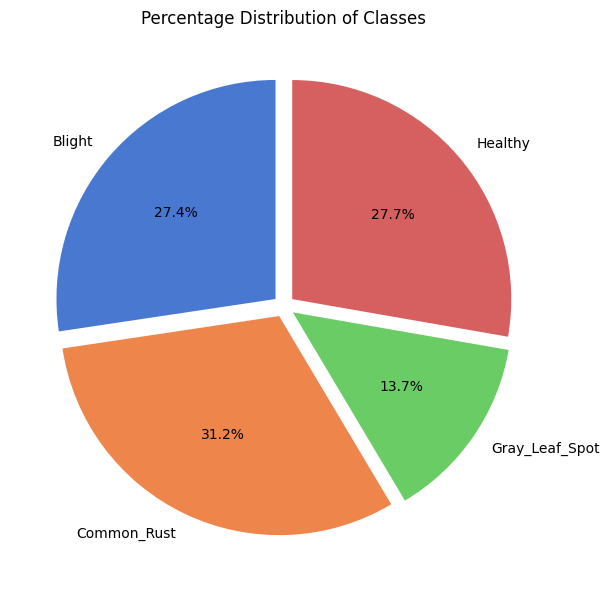

In [ ]:
class_names=dataset.class_names

class_counts = {}
for images, labels in dataset.as_numpy_iterator():
    for label in labels:
        class_label = class_names[label]
        if class_label in class_counts:
            class_counts[class_label] += 1
        else:
            class_counts[class_label] = 1


counts = [class_counts.get(class_name, 0) for class_name in class_names]

df = pd.DataFrame({
    'Class': class_names,
    'Count': counts
})


plt.figure(figsize=(7, 6))
df.set_index('Class')['Count'].plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'),
                                        startangle=90, explode=[0.05]*len(class_names))
plt.title('Percentage Distribution of Classes')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
images = []
labels = []

target_size = (128,128)

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_dir):
        img_path = os.path.join(cls_dir, img_name)
        img = cv2.imread(img_path)
        if img is not None:

            img = cv2.resize(img, target_size)

            img = img.astype('float32') / 255.0
            images.append(img)
            labels.append(idx)


X = np.array(images)
y = np.array(labels)

print("All images loaded successfully!")
print("Data shape:", X.shape)
print("Labels shape:", y.shape)


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")


All images loaded successfully!
Data shape: (4188, 128, 128, 3)
Labels shape: (4188,)
Training set: (2931, 128, 128, 3), Validation set: (628, 128, 128, 3), Test set: (629, 128, 128, 3)


In [ ]:
# @title
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[3 0 2 2 0 1 0 1 1 3 1 3 1 1 1 2 3 2 0 0 2 3 0 3 0 0 3 1 3 3 0 0]


In [ ]:
# @title
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].shape)

(256, 256, 3)


In [ ]:
model_custom = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),


    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model_custom.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,529,316 (32.54 MB)

 Trainable params: 8,529,316 (32.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_custom.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_custom = model_custom.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.5107 - loss: 1.5187 - val_accuracy: 0.8264 - val_loss: 0.5837
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.8116 - loss: 0.5463 - val_accuracy: 0.8471 - val_loss: 0.4526
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8381 - loss: 0.4695 - val_accuracy: 0.8503 - val_loss: 0.4270
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8536 - loss: 0.4138 - val_accuracy: 0.8710 - val_loss: 0.3823
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8577 - loss: 0.4033 - val_accuracy: 0.8503 - val_loss: 0.4449
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8440 - loss: 0.4347 - val_accuracy: 0.8535 - val_loss: 0.4109
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.8680 - loss: 0.3915 - val_accuracy: 0.8838 - val_loss: 0.3622
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8877 - loss: 0.3609 - val_accuracy: 0.8806 - v

In [ ]:
test_loss, test_acc = model_custom.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 415ms/step - accuracy: 0.9348 - loss: 0.3494
Test Accuracy: 0.9237 | Test Loss: 0.3725


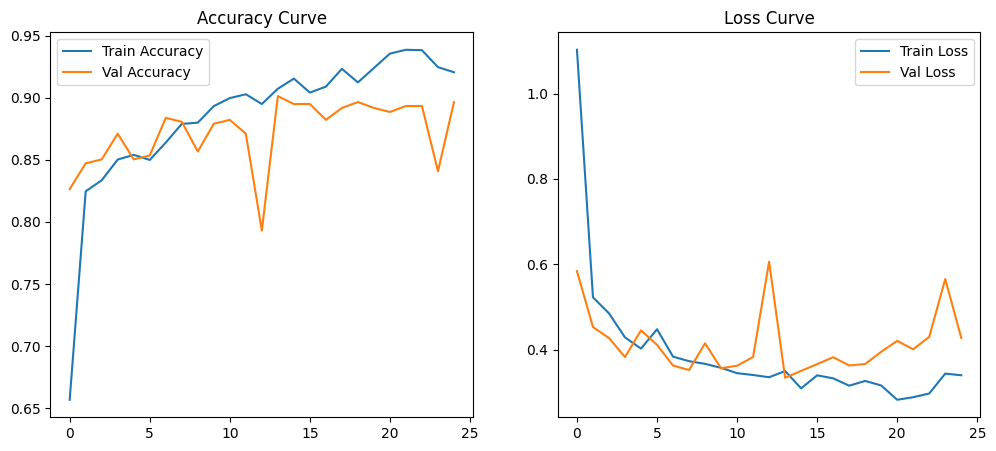

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_custom.history['accuracy'], label='Train Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy Curve')

plt.subplot(1,2,2)
plt.plot(history_custom.history['loss'], label='Train Loss')
plt.plot(history_custom.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step
Classification Report:

                precision    recall  f1-score   support

   Common_Rust       0.97      0.96      0.97       196
        Blight       0.83      0.94      0.88       172
       Healthy       1.00      1.00      1.00       175
Gray_Leaf_Spot       0.85      0.65      0.74        86

      accuracy                           0.92       629
     macro avg       0.91      0.89      0.90       629
  weighted avg       0.92      0.92      0.92       629



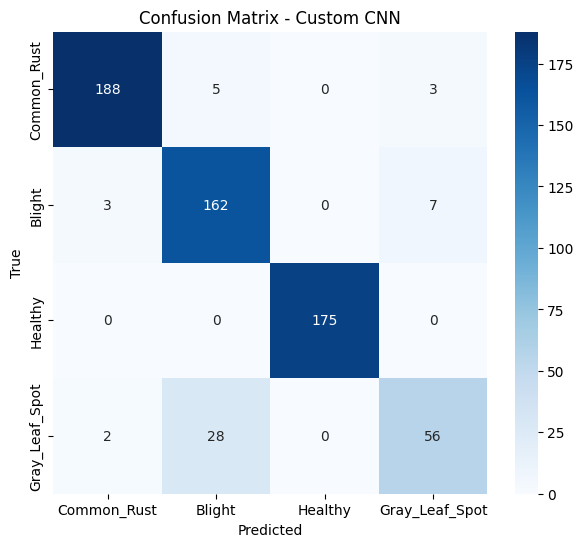

In [ ]:
y_pred = np.argmax(model_custom.predict(X_test), axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - Custom CNN")
plt.show()

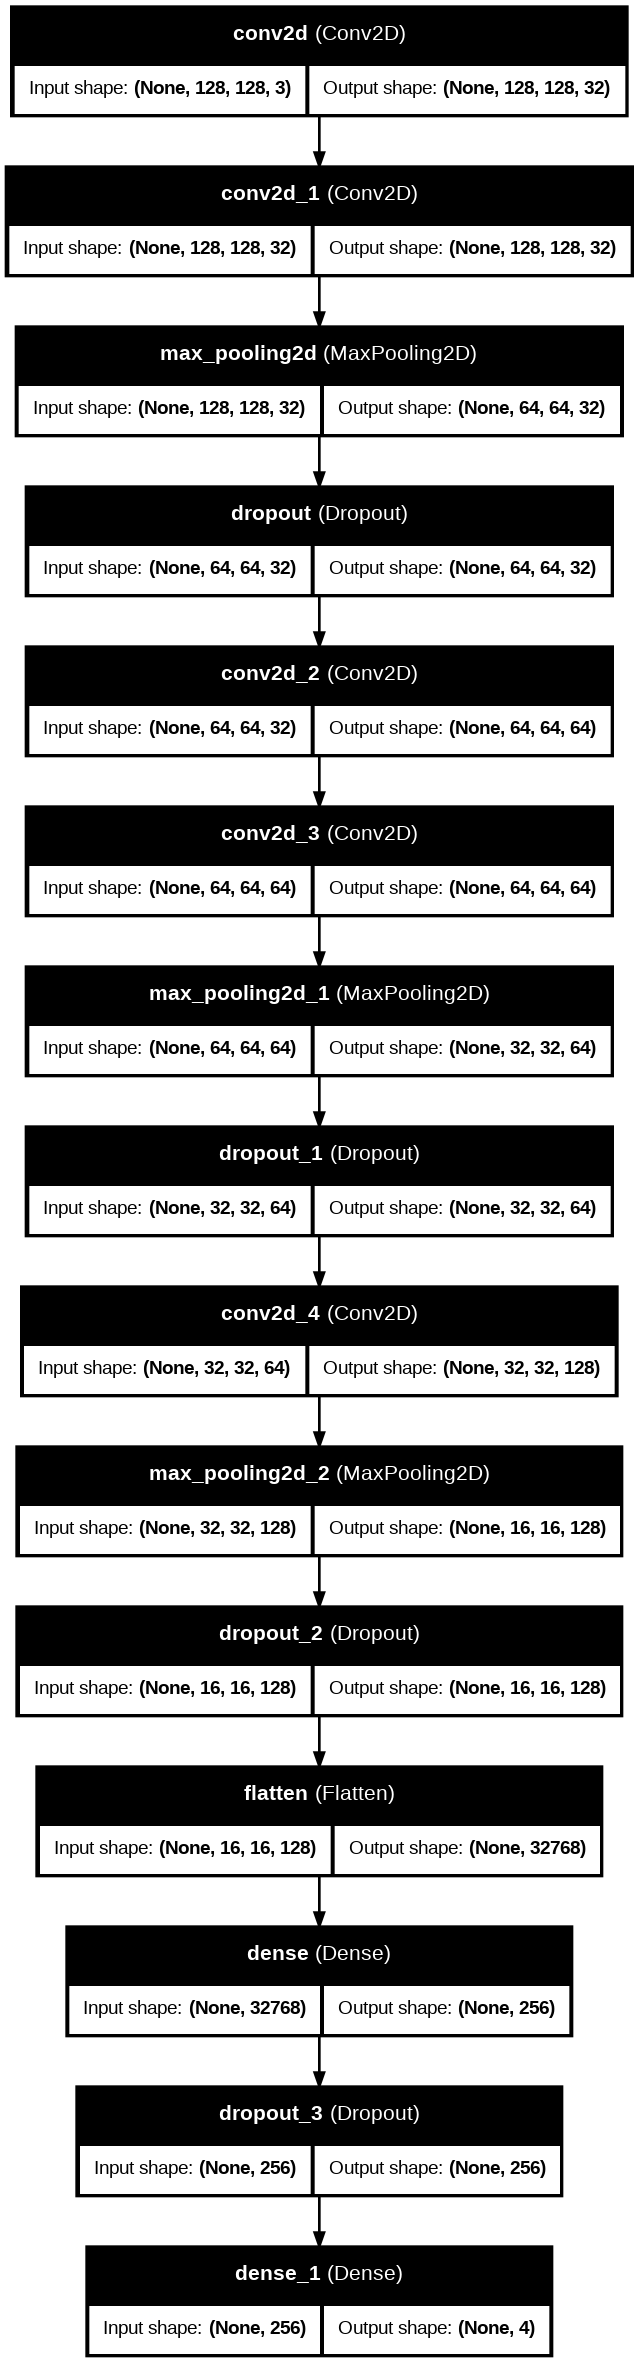

In [ ]:
plot_model(
    model_custom,
    to_file="custom_cnn_structure.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

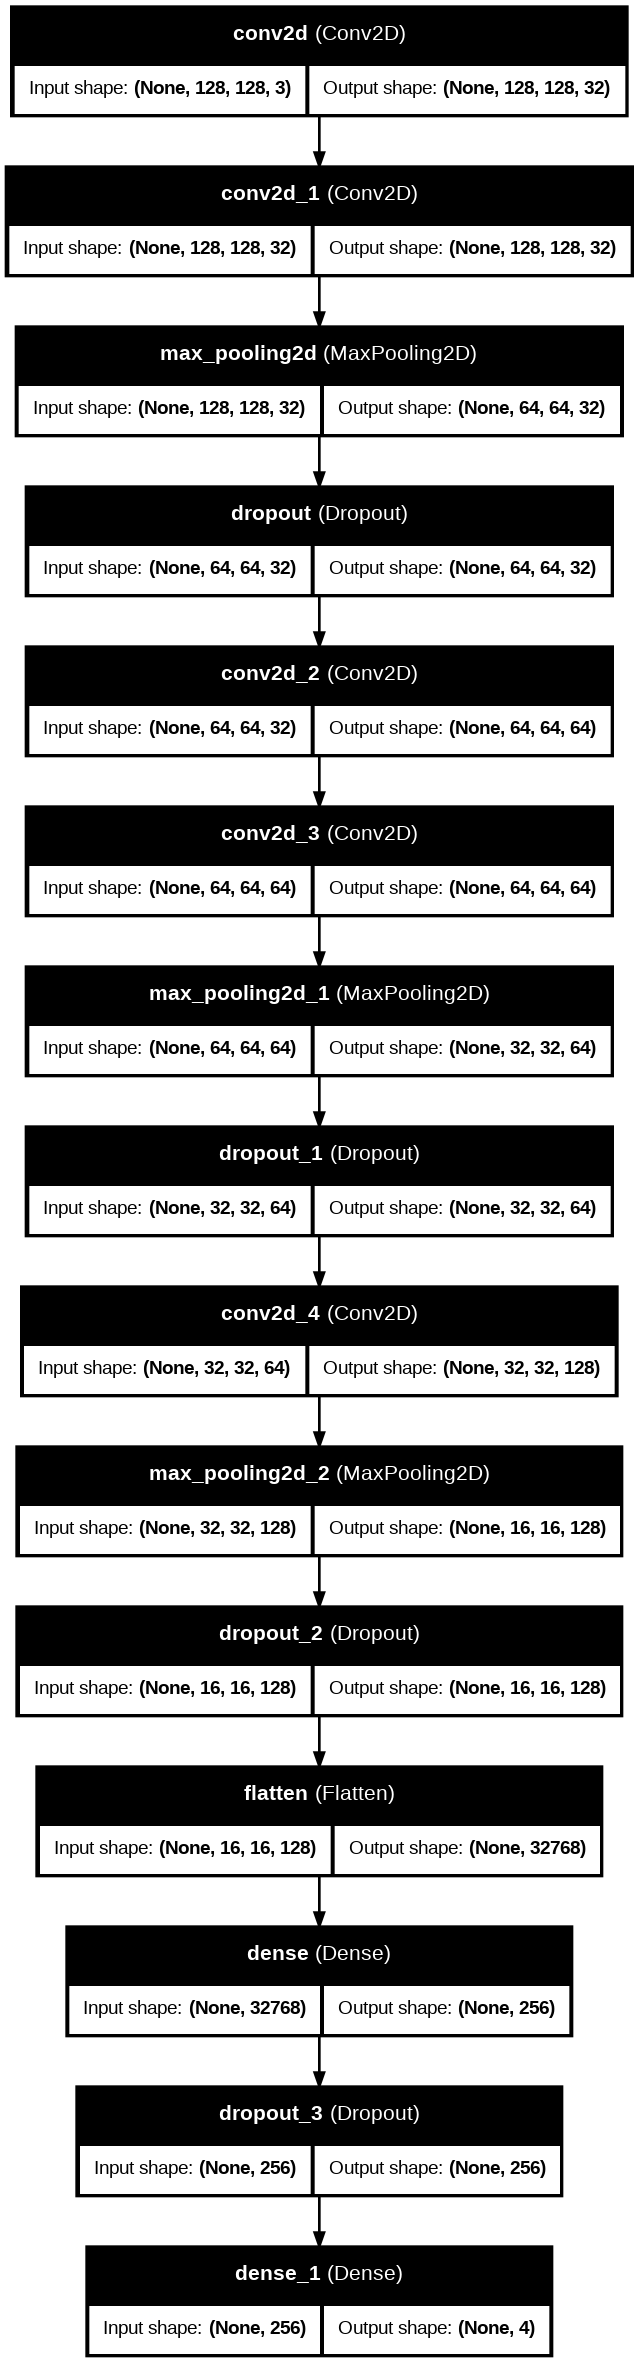

In [ ]:
# @title
plot_model(
    model_custom,
    to_file="custom_cnn_structure.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)


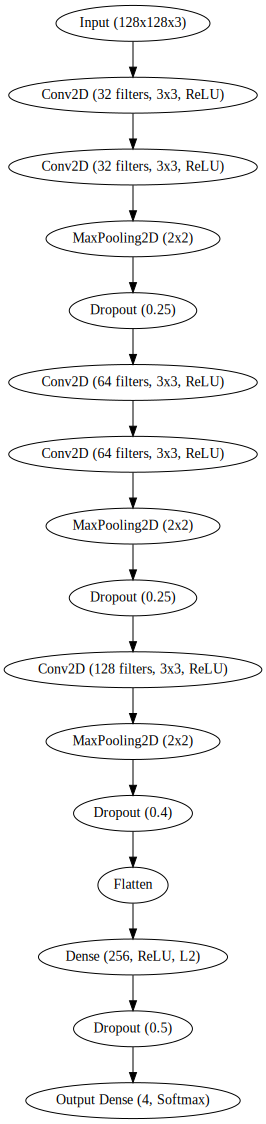

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Custom CNN Architecture')

dot.node('I', 'Input (128x128x3)')
dot.node('C1', 'Conv2D (32 filters, 3x3, ReLU)')
dot.node('C2', 'Conv2D (32 filters, 3x3, ReLU)')
dot.node('P1', 'MaxPooling2D (2x2)')
dot.node('D1', 'Dropout (0.25)')
dot.node('C3', 'Conv2D (64 filters, 3x3, ReLU)')
dot.node('C4', 'Conv2D (64 filters, 3x3, ReLU)')
dot.node('P2', 'MaxPooling2D (2x2)')
dot.node('D2', 'Dropout (0.25)')
dot.node('C5', 'Conv2D (128 filters, 3x3, ReLU)')
dot.node('P3', 'MaxPooling2D (2x2)')
dot.node('D3', 'Dropout (0.4)')
dot.node('F', 'Flatten')
dot.node('FC1', 'Dense (256, ReLU, L2)')
dot.node('D4', 'Dropout (0.5)')
dot.node('O', 'Output Dense (4, Softmax)')

dot.edges([('I', 'C1'), ('C1', 'C2'), ('C2', 'P1'), ('P1', 'D1'), ('D1', 'C3'), ('C3', 'C4'), ('C4', 'P2'), ('P2', 'D2'), ('D2', 'C5'), ('C5', 'P3'), ('P3', 'D3'), ('D3', 'F'), ('F', 'FC1'), ('FC1', 'D4'), ('D4', 'O')])

dot.render('custom_cnn_graph', format='png', cleanup=True)
dot

# ResNet

In [ ]:
start_time = time()

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)



for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,668 (92.11 MB)

 Trainable params: 557,956 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet = model_resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.2547 - loss: 1.4937 - val_accuracy: 0.5032 - val_loss: 1.3216
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.3399 - loss: 1.3684 - val_accuracy: 0.5207 - val_loss: 1.3043
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.3551 - loss: 1.3333 - val_accuracy: 0.5127 - val_loss: 1.2813
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3684 - loss: 1.3234 - val_accuracy: 0.5255 - val_loss: 1.2474
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.4106 - loss: 1.2858 - val_accuracy: 0.5303 - val_loss: 1.1998
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4429 - loss: 1.2459 - val_accuracy: 0.5271 - val_loss: 1.1551
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4742 - loss: 1.2044 - val_accuracy: 0.5239 - val_loss: 1.1183
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4906 - loss: 1.1699 - val_accuracy: 0.

In [ ]:
end_time = time()
print(f"\n Total training time: {(end_time - start_time)/60:.2f} minutes")


 Total training time: 178.03 minutes


In [ ]:
test_loss, test_acc = model_resnet.evaluate(X_test, y_test)
print(f"\n Test Accuracy: {test_acc:.2f}")
print(f"Test Loss: {test_loss:.2f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 877ms/step - accuracy: 0.7845 - loss: 0.4962

 Test Accuracy: 0.77
Test Loss: 0.53


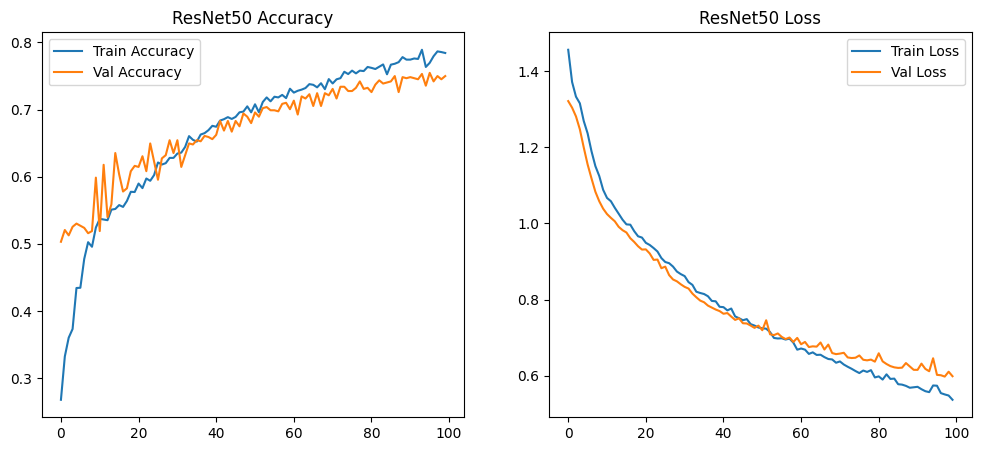

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Loss')
plt.legend()

plt.show()

In [ ]:
custom_test_loss, custom_test_acc = model_custom.evaluate(X_test, y_test)
resnet_test_loss, resnet_test_acc = model_resnet.evaluate(X_test, y_test)


print(f"\n Performance Comparison:")
print(f"Custom CNN - Accuracy: {custom_test_acc:.4f}, Loss: {custom_test_loss:.4f}")
print(f"ResNet50   - Accuracy: {resnet_test_acc:.4f}, Loss: {resnet_test_loss:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 407ms/step - accuracy: 0.9348 - loss: 0.3494
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 879ms/step - accuracy: 0.7845 - loss: 0.4962

 Performance Comparison:
Custom CNN - Accuracy: 0.9237, Loss: 0.3725
ResNet50   - Accuracy: 0.7742, Loss: 0.5277


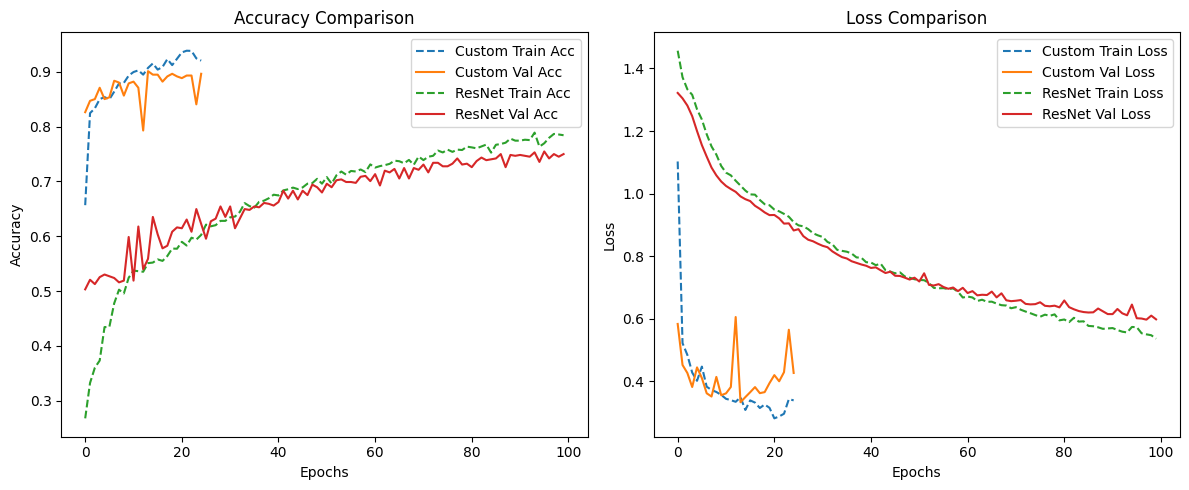

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'], label='Custom Train Acc', linestyle='--')
plt.plot(history_custom.history['val_accuracy'], label='Custom Val Acc')
plt.plot(history_resnet.history['accuracy'], label='ResNet Train Acc', linestyle='--')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet Val Acc')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'], label='Custom Train Loss', linestyle='--')
plt.plot(history_custom.history['val_loss'], label='Custom Val Loss')
plt.plot(history_resnet.history['loss'], label='ResNet Train Loss', linestyle='--')
plt.plot(history_resnet.history['val_loss'], label='ResNet Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 402ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
 Custom CNN Report
                precision    recall  f1-score   support

        Blight       0.97      0.96      0.97       196
   Common_Rust       0.83      0.94      0.88       172
Gray_Leaf_Spot       1.00      1.00      1.00       175
       Healthy       0.85      0.65      0.74        86

      accuracy                           0.92       629
     macro avg       0.91      0.89      0.90       629
  weighted avg       0.92      0.92      0.92       629


 ResNet50 Report
                precision    recall  f1-score   support

        Blight       0.91      0.95      0.93       196
   Common_Rust       0.62      0.70      0.66       172
Gray_Leaf_Spot       0.84      0.87      0.85       175
       Healthy       0.61      0.33      0.42        86

      accuracy                           0.77       629
     macro avg       0.74      0.71      0.72       629
  weighted avg       0.77      0.77   

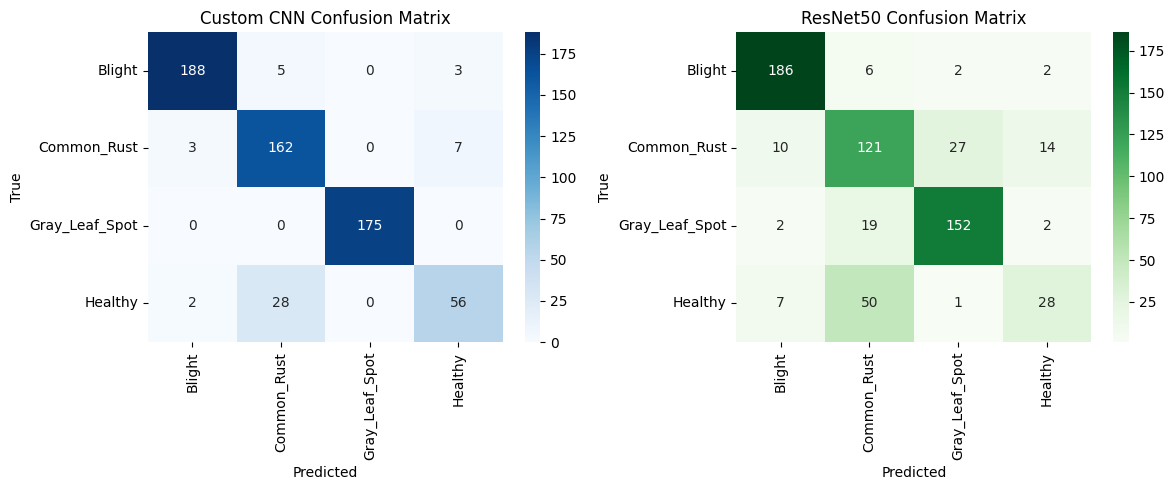

In [ ]:
y_pred_custom = np.argmax(model_custom.predict(X_test), axis=1)
y_pred_resnet = np.argmax(model_resnet.predict(X_test), axis=1)


print(" Custom CNN Report")
print(classification_report(y_test, y_pred_custom, target_names=class_names))

print("\n ResNet50 Report")
print(classification_report(y_test, y_pred_resnet, target_names=class_names))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, cmap="Blues", fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_resnet), annot=True, cmap="Greens", fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()
